# 01 — Data Collection & Feature Engineering

This notebook:

1. Downloads SPY daily OHLCV via `yfinance` (2004-present)
2. Loads supplementary data: CBOE put/call ratio, AAII sentiment
3. Applies all feature engineering transforms
4. Performs a chronological train/val/test split
5. Saves the processed dataset to `data/processed/`

**Supplementary data — manual steps required:**

- Put/call ratio: download from https://www.cboe.com/us/options/market_statistics/daily/  
  Save as `data/raw/put_call_ratio.csv`
- AAII sentiment: download from https://www.aaii.com/sentimentsurvey/sent_results  
  Save as `data/raw/aaii_sentiment.csv`

The pipeline will proceed without these files (producing NaN columns) and
will warn you where they are missing.


In [1]:
import sys

sys.path.insert(0, "..")

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import setup_logging

setup_logging()

from config import (
    TICKER,
    START_DATE,
    END_DATE,
    TRAIN_END,
    VAL_END,
    VOL_WINDOW,
    ROLLING_WINDOWS,
    DATA_RAW,
    DATA_PROCESSED,
)

print("Config loaded.")
print(f"  Ticker      : {TICKER}")
print(f'  Date range  : {START_DATE} → {END_DATE or "today"}')
print(f"  Train end   : {TRAIN_END}")
print(f"  Val end     : {VAL_END}")
print(f"  Vol window  : {VOL_WINDOW} days")

Config loaded.
  Ticker      : SPY
  Date range  : 2001-04-01 → today
  Train end   : 2018-12-31
  Val end     : 2021-12-31
  Vol window  : 21 days


## 1. Download SPY OHLCV


In [2]:
from src.data_loader import download_spy

ohlcv = download_spy(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    force_refresh=True,
)

print(f"OHLCV shape: {ohlcv.shape}")
print(f"Date range : {ohlcv.index.min().date()} → {ohlcv.index.max().date()}")
print(f"Trading days: {len(ohlcv)}")
ohlcv.tail()

01:31:52 | INFO    | src.data_loader | Downloading SPY OHLCV from Yahoo Finance (2001-04-01 → today)…
01:31:52 | INFO    | src.data_loader | Cached SPY OHLCV → /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/raw/SPY_ohlcv.parquet


OHLCV shape: (6302, 5)
Date range : 2001-04-02 → 2026-04-23
Trading days: 6302


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-17,706.140015,712.390015,705.760010,710.140015,70661900
2026-04-20,708.780029,709.909973,706.140015,708.719971,43546800
2026-04-21,710.280029,711.280029,702.640015,704.080017,58941400
2026-04-22,709.150024,711.450012,708.219971,711.210022,42518500
2026-04-23,709.500000,712.359985,702.280029,708.450012,56047300


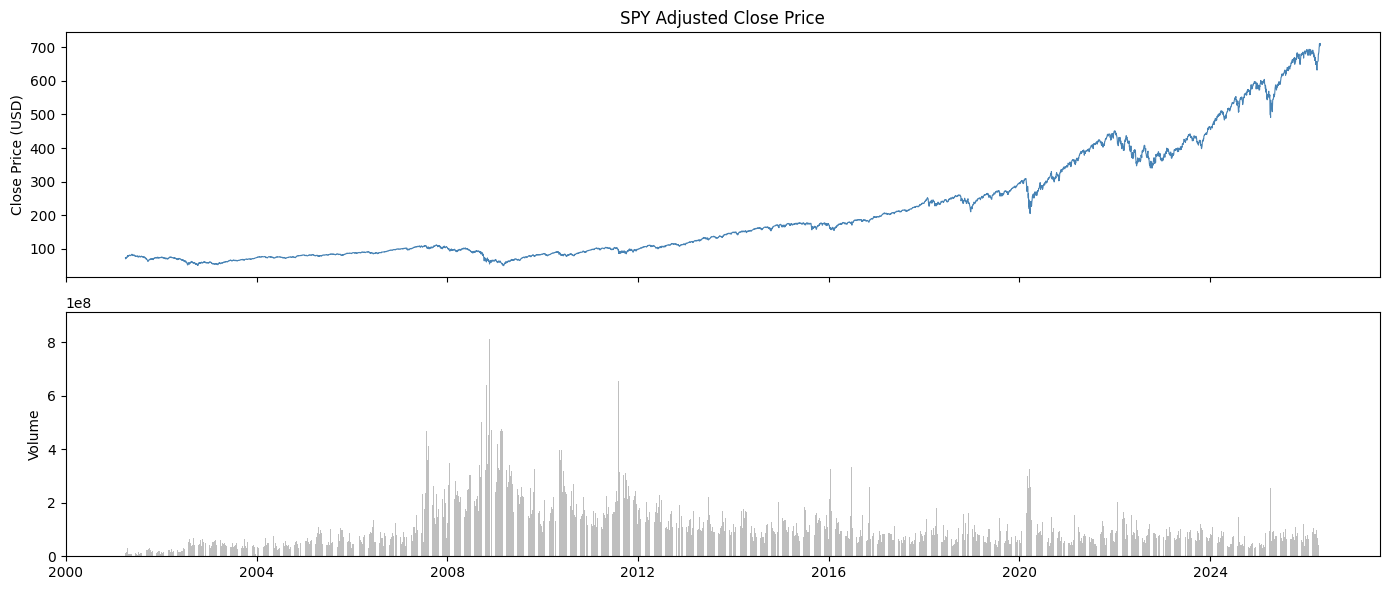

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue")
axes[0].set_ylabel("Close Price (USD)")
axes[0].set_title("SPY Adjusted Close Price")
axes[1].bar(ohlcv.index, ohlcv["Volume"], width=1, color="gray", alpha=0.5)
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()

## 2. Load supplementary data


In [4]:
from src.data_loader import load_putcall_ratio, load_aaii_sentiment

pc_ratio = load_putcall_ratio(raw_dir=DATA_RAW)
sentiment = load_aaii_sentiment(raw_dir=DATA_RAW)

if pc_ratio.empty:
    print("⚠ Put/call ratio not found — will proceed without it.")
else:
    print(
        f"Put/call ratio: {len(pc_ratio)} rows, {pc_ratio.index.min().date()} → {pc_ratio.index.max().date()}"
    )

if sentiment.empty:
    print("⚠ AAII sentiment not found — will proceed without it.")
else:
    print(
        f"AAII sentiment: {len(sentiment)} rows, {sentiment.index.min().date()} → {sentiment.index.max().date()}"
    )
    print(sentiment.tail())

01:31:54 | WARNING | src.data_loader | Put/call ratio CSV not found. Download from https://www.cboe.com/us/options/market_statistics/daily/ and save as data/raw/put_call_ratio.csv


⚠ Put/call ratio not found — will proceed without it.
AAII sentiment: 2023 rows, 1987-06-26 → 2026-04-23
             bullish   bearish   neutral  bull_bear_spread
date                                                      
2026-03-26  0.320988  0.497942  0.181070         -0.176954
2026-04-02  0.335714  0.514286  0.150000         -0.178572
2026-04-09  0.357466  0.429864  0.212670         -0.072398
2026-04-16  0.317308  0.427885  0.254808         -0.110577
2026-04-23  0.460465  0.344186  0.195349          0.116279


## 3. Build the merged raw dataset


In [5]:
from src.data_loader import build_raw_dataset

raw_df = build_raw_dataset(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    processed_dir=DATA_PROCESSED,
)

print(f"\nRaw dataset shape: {raw_df.shape}")
print("Columns:", raw_df.columns.tolist())
print("\nMissing values:")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
raw_df.tail()

01:31:54 | INFO    | src.data_loader | Loading merged raw dataset from cache: /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet



Raw dataset shape: (5606, 5)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Missing values:
Series([], dtype: int64)


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-09,674.840027,681.159973,673.770020,679.909973,57134400
2026-04-10,681.320007,682.030029,678.450012,679.460022,42253500
2026-04-13,677.409973,686.299988,676.580017,686.099976,54185800
2026-04-14,687.690002,694.580017,687.659973,694.460022,63480500
2026-04-15,695.260010,700.280029,694.200012,699.940002,58138100


## 4. Feature engineering


In [6]:
from src.features import build_features

feat_df = build_features(
    raw_df,
    vol_window=VOL_WINDOW,
    rolling_windows=ROLLING_WINDOWS,
    annualise_target=False,
)

print(f"Feature dataset shape: {feat_df.shape}")
print("Columns:", feat_df.columns.tolist())

01:31:54 | INFO    | src.features | Feature build complete. Rows with NaN: 1 leading (lag), ~20 trailing (forward target).


Feature dataset shape: (5606, 23)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21', 'realized_vol_21d', 'bullish', 'bearish']


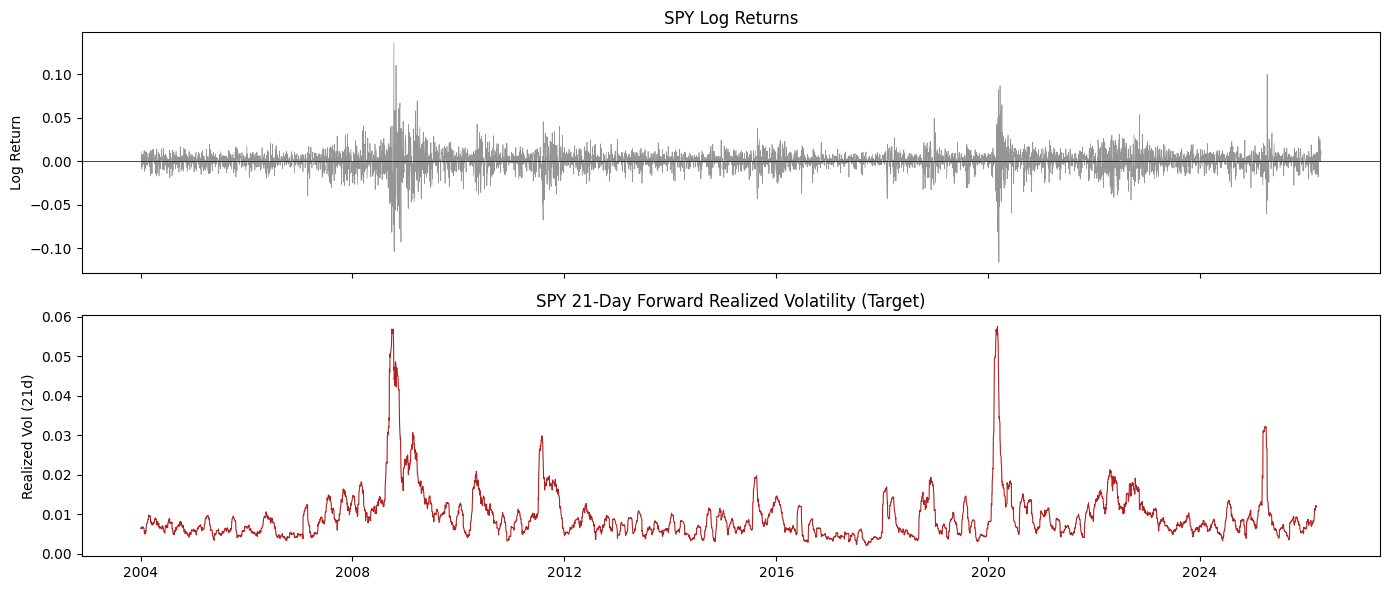

In [7]:
# Quick sanity check: inspect log returns and the target vol
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(
    feat_df.index, feat_df["log_return"], linewidth=0.5, color="dimgray", alpha=0.7
)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Log Return")
axes[0].set_title("SPY Log Returns")

axes[1].plot(
    feat_df.index, feat_df["realized_vol_21d"], linewidth=0.8, color="firebrick"
)
axes[1].set_ylabel("Realized Vol (21d)")
axes[1].set_title("SPY 21-Day Forward Realized Volatility (Target)")
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics of all engineered features
feat_df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,5606.0,2.239453e+02,1.631127e+02,4.969160e+01,9.481310e+01,1.664791e+02,3.115805e+02,6.952600e+02
High,5606.0,2.251799e+02,1.639315e+02,5.119070e+01,9.533380e+01,1.673566e+02,3.135810e+02,7.002800e+02
Low,5606.0,2.226010e+02,1.622129e+02,4.907000e+01,9.397400e+01,1.652285e+02,3.098250e+02,6.942000e+02
Close,5606.0,2.239801e+02,1.631527e+02,4.980860e+01,9.469480e+01,1.665707e+02,3.115388e+02,6.999400e+02
Volume,5606.0,1.190302e+08,8.919273e+07,1.527000e+07,6.243975e+07,8.909105e+07,1.463314e+08,8.710263e+08
log_return,5605.0,4.000000e-04,1.180000e-02,-1.159000e-01,-3.900000e-03,7.000000e-04,5.800000e-03,1.356000e-01
abs_return,5605.0,7.600000e-03,9.100000e-03,0.000000e+00,2.000000e-03,5.000000e-03,1.010000e-02,1.356000e-01
oc_return,5606.0,1.000000e-04,9.200000e-03,-9.420000e-02,-3.600000e-03,6.000000e-04,4.400000e-03,1.060000e-01
intraday_range,5606.0,-4.614400e+00,6.167000e-01,-6.701500e+00,-5.042300e+00,-4.654300e+00,-4.240800e+00,-2.145100e+00


In [9]:
feat_df

Price,Open,High,Low,Close,Volume,log_return,abs_return,oc_return,intraday_range,log_volume,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,realized_vol_21d,bullish,bearish
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,74.172417,74.471127,73.501988,73.833885,38072300,NaN,NaN,-0.004575,-4.333164,17.454998,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006447,0.624100,0.134800
2004-01-05,74.139262,74.690208,74.072878,74.637108,27959800,0.010820,0.010820,0.006693,-4.794990,17.146278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006351,0.624100,0.134800
2004-01-06,74.451211,74.829574,74.345002,74.710091,20472800,0.000977,0.000977,0.003471,-5.038104,16.834608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006376,0.624100,0.134800
2004-01-07,74.603892,75.048633,74.271994,74.962341,30170400,0.003371,0.003371,0.004793,-4.569766,17.222372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006761,0.624100,0.134800
2004-01-08,75.174756,75.280965,74.856132,75.261047,36438400,0.003977,0.003977,0.001147,-5.177021,17.411134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006720,0.671600,0.179100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,674.840027,681.159973,673.770020,679.909973,57134400,0.005753,0.005753,0.007485,-4.521839,17.860917,...,0.007392,0.003455,0.015197,0.011169,0.000321,0.012523,0.009381,NaN,0.357466,0.429864
2026-04-10,681.320007,682.030029,678.450012,679.460022,42253500,-0.000662,0.000662,-0.002734,-5.245931,17.559198,...,0.007344,0.005191,0.013351,0.009433,0.000350,0.012520,0.009353,NaN,0.357466,0.429864
2026-04-13,677.409973,686.299988,676.580017,686.099976,54185800,0.009725,0.009725,0.012747,-4.256841,17.807929,...,0.008346,0.007883,0.010807,0.008685,0.001541,0.012141,0.009087,NaN,0.357466,0.429864


## 5. Chronological train / val / test split


In [10]:
from src.features import time_split
from src.utils import describe_splits

# Drop rows with NaN in target or core features before splitting
target_col = f"realized_vol_{VOL_WINDOW}d"
clean_df = feat_df.dropna(subset=["log_return", target_col])
print(f"Rows before dropping NaN: {len(feat_df):,}")
print(f"Rows after  dropping NaN: {len(clean_df):,}")

train, val, test = time_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)
print()
print(describe_splits(train, val, test))

01:31:54 | INFO    | src.features | Split sizes — Train: 3774, Val: 757, Test: 1053


Rows before dropping NaN: 5,606
Rows after  dropping NaN: 5,584

                 Start         End  Days
Split                                   
Train       2004-01-05  2018-12-31  3774
Validation  2019-01-02  2021-12-31   757
Test        2022-01-03  2026-03-16  1053


In [11]:
train

Price,Open,High,Low,Close,Volume,log_return,abs_return,oc_return,intraday_range,log_volume,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,realized_vol_21d,bullish,bearish
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-05,74.139262,74.690208,74.072878,74.637108,27959800,0.010820,0.010820,0.006693,-4.794990,17.146278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006351,0.624100,0.134800
2004-01-06,74.451211,74.829574,74.345002,74.710091,20472800,0.000977,0.000977,0.003471,-5.038104,16.834608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006376,0.624100,0.134800
2004-01-07,74.603892,75.048633,74.271994,74.962341,30170400,0.003371,0.003371,0.004793,-4.569766,17.222372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006761,0.624100,0.134800
2004-01-08,75.174756,75.280965,74.856132,75.261047,36438400,0.003977,0.003977,0.001147,-5.177021,17.411134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006720,0.671600,0.179100
2004-01-09,74.895945,75.340687,74.524217,74.603874,54084300,-0.008770,0.008770,-0.003907,-4.514958,17.806055,...,0.005583,NaN,NaN,NaN,NaN,NaN,NaN,0.006414,0.671600,0.179100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,214.391211,216.005605,210.113083,210.175858,147311600,-0.026778,0.026778,-0.019858,-3.574260,18.808061,...,0.016016,-0.011362,0.011147,0.012412,-0.005581,0.014907,0.012107,0.014359,0.248649,0.472973
2018-12-26,211.637801,220.794983,209.655681,220.794983,218485400,0.049290,0.049290,0.042358,-2.986755,19.202230,...,0.025654,-0.006456,0.022166,0.017318,-0.002915,0.019111,0.014135,0.010882,0.248649,0.472973
2018-12-27,217.557278,222.687445,214.319525,222.490143,186267300,0.007648,0.007648,0.022421,-3.280477,19.042693,...,0.024166,-0.006193,0.022332,0.017581,-0.003314,0.018781,0.013736,0.010879,0.315476,0.502976


In [12]:
train.isna().sum()

Price
Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
log_return              0
abs_return              0
oc_return               0
intraday_range          0
log_volume              0
relative_volume_21d    19
rolling_mean_5          4
rolling_std_5           4
rolling_abs_mean_5      4
rolling_mean_10         9
rolling_std_10          9
rolling_abs_mean_10     9
rolling_mean_21        20
rolling_std_21         20
rolling_abs_mean_21    20
realized_vol_21d        0
bullish                 0
bearish                 0
dtype: int64

In [13]:
test

Price,Open,High,Low,Close,Volume,log_return,abs_return,oc_return,intraday_range,log_volume,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,realized_vol_21d,bullish,bearish
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,449.314353,450.776552,447.003179,450.644470,72668200,0.005773,0.005773,0.002956,-4.782709,18.101414,...,0.002632,0.003806,0.008589,0.007166,0.002236,0.010097,0.008681,0.011527,0.376569,0.305439
2022-01-04,452.068895,452.785845,448.635113,450.493500,71178700,-0.000335,0.000335,-0.003491,-4.687059,18.080704,...,0.002536,0.004842,0.007151,0.006130,0.002636,0.009802,0.008281,0.012406,0.376569,0.305439
2022-01-05,450.125568,450.899117,441.748678,441.843018,104538900,-0.019389,0.019389,-0.018572,-3.877153,18.465070,...,0.006158,0.001142,0.009114,0.006309,0.001152,0.010670,0.008643,0.011961,0.376569,0.305439
2022-01-06,441.380823,444.144811,439.060178,441.427979,86858900,-0.000940,0.000940,0.000107,-4.463792,18.279796,...,0.005792,0.000053,0.008580,0.005408,0.000132,0.009711,0.007713,0.011961,0.327586,0.333333
2022-01-07,441.437464,442.616643,438.324414,439.682831,85111600,-0.003961,0.003961,-0.003983,-4.629247,18.259474,...,0.006080,-0.000963,0.008370,0.005184,-0.000182,0.009733,0.007776,0.012152,0.327586,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-10,675.874140,681.498793,672.922240,675.335632,81505300,-0.001608,0.001608,-0.000797,-4.366178,18.216179,...,0.007229,-0.001491,0.007562,0.006435,-0.000936,0.007198,0.005824,0.012221,0.330579,0.355372
2026-03-11,675.734572,678.227763,671.506129,674.487976,68441700,-0.001256,0.001256,-0.001847,-4.608623,18.041493,...,0.006074,-0.002457,0.006729,0.005721,-0.001225,0.007076,0.005655,0.012218,0.330579,0.355372
2026-03-12,669.331996,669.820712,664.056426,664.245911,108882200,-0.015301,0.015301,-0.007628,-4.746971,18.505777,...,0.008016,-0.003430,0.007841,0.006694,-0.001828,0.007714,0.006257,0.011848,0.319392,0.463878


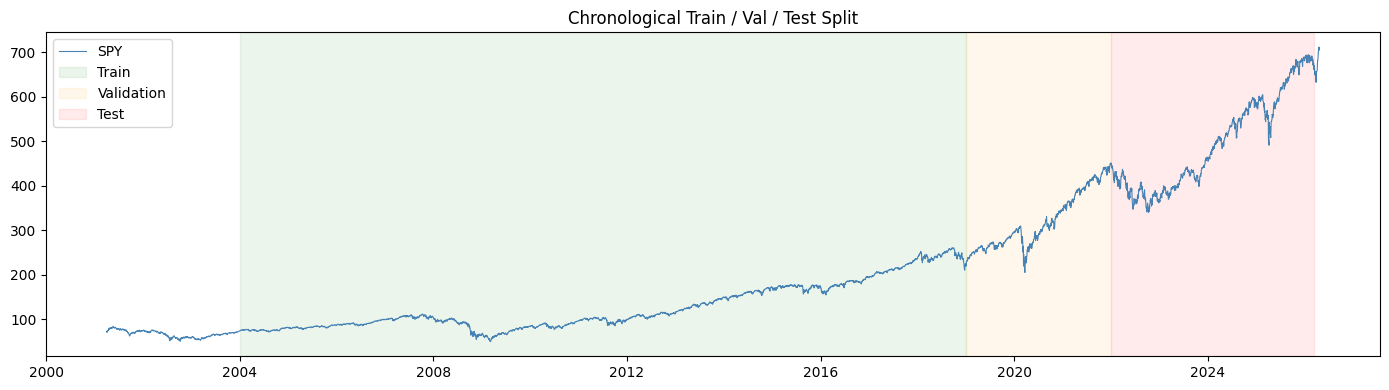

In [14]:
# Visualise the split boundaries on the price chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue", label="SPY")
ax.axvspan(
    train.index.min(), train.index.max(), alpha=0.08, color="green", label="Train"
)
ax.axvspan(
    val.index.min(), val.index.max(), alpha=0.08, color="orange", label="Validation"
)
ax.axvspan(test.index.min(), test.index.max(), alpha=0.08, color="red", label="Test")
ax.legend()
ax.set_title("Chronological Train / Val / Test Split")
plt.tight_layout()
plt.show()

## 6. Save processed datasets


In [15]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

clean_df.to_parquet(DATA_PROCESSED / "features_all.parquet")
train.to_parquet(DATA_PROCESSED / "train.parquet")
val.to_parquet(DATA_PROCESSED / "val.parquet")
test.to_parquet(DATA_PROCESSED / "test.parquet")

print("Saved:")
for p in DATA_PROCESSED.glob("*.parquet"):
    print(f"  {p}")

Saved:
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/train.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/test_predictions.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/test.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/val.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/features_all.parquet
  /Users/maharajhaider/gitrepo/StockVolatilitySight/notebooks/../data/processed/regime_probabilities.parquet


## 7. Feature correlation check


In [16]:
from src.features import drop_correlated_features, variance_inflation_check
from src.utils import plot_correlation_matrix

# All engineered numeric features (exclude raw OHLCV and target)
exclude = ["Open", "High", "Low", "Close", "Volume", target_col]
all_feature_cols = [c for c in clean_df.columns if c not in exclude]

print(f"All feature columns ({len(all_feature_cols)}): {all_feature_cols}")

All feature columns (17): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21', 'bullish', 'bearish']


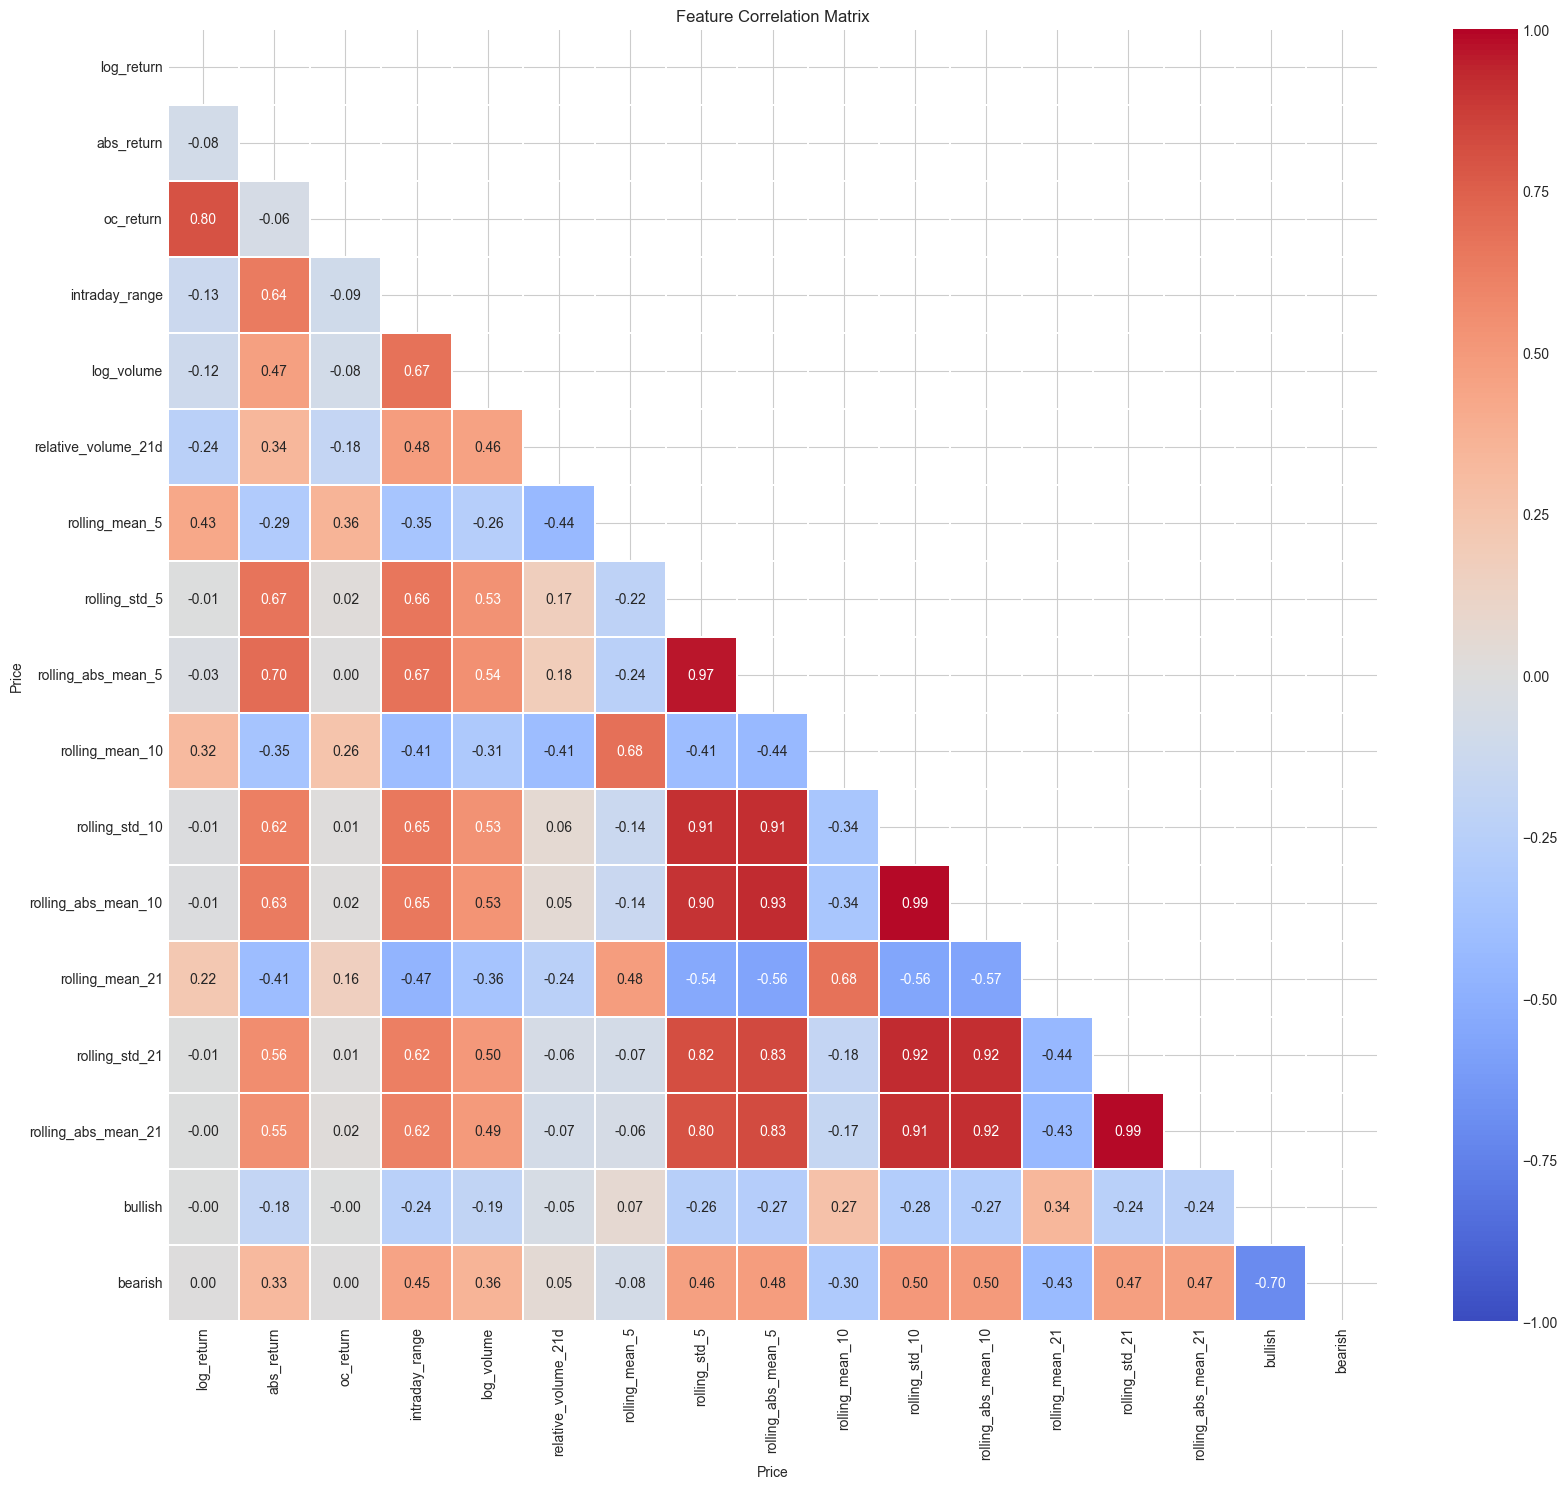

In [17]:
fig = plot_correlation_matrix(clean_df, all_feature_cols)
plt.show()

In [18]:
kept_features = drop_correlated_features(clean_df, all_feature_cols, threshold=0.95)
print(f"Features after correlation pruning ({len(kept_features)}): {kept_features}")

01:31:55 | INFO    | src.features | Dropping correlated features (threshold=0.95): ['rolling_abs_mean_5', 'rolling_abs_mean_10', 'rolling_abs_mean_21']


Features after correlation pruning (14): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21', 'bullish', 'bearish']


In [19]:
vif_df = variance_inflation_check(clean_df, kept_features)
print("VIF scores:")
print(vif_df.to_string(index=False))

01:31:55 | WARNING | src.features | Features with VIF > 10.0 (potential multicollinearity):
            feature        VIF
         log_volume 372.052212
     intraday_range 130.804389
     rolling_std_10  41.816952
            bullish  36.351130
            bearish  34.594960
     rolling_std_21  28.978408
relative_volume_21d  22.318144
      rolling_std_5  16.543725


VIF scores:
            feature        VIF
         log_volume 372.052212
     intraday_range 130.804389
     rolling_std_10  41.816952
            bullish  36.351130
            bearish  34.594960
     rolling_std_21  28.978408
relative_volume_21d  22.318144
      rolling_std_5  16.543725
         abs_return   3.645597
    rolling_mean_10   3.242116
         log_return   3.028986
          oc_return   2.800498
    rolling_mean_21   2.650742
     rolling_mean_5   2.399288


## Summary

| Item                   | Value |
| ---------------------- | ----- |
| Total trading days (after dropna) | **5,564** |
| Raw engineered feature columns | **15** (before VIF / correlation pruning) |
| Features after correlation pruning | **12** (used for splits & downstream; HMM uses an 11-feature subset per `config`) |
| Train / Val / Test rows | **3,774 / 757 / 1,053** (chronological; train **2004-01-05 → 2018-12-31**, val **2019-01-02 → 2021-12-31**, test **2022-01-03 → 2026-03-16**) |
| Target                 | 21-day forward realized volatility (`realized_vol_21d`) |

Artifacts written under `data/processed/` include `train.parquet`, `val.parquet`, `test.parquet`, `features_all.parquet`, and `regime_probabilities.parquet` (after HMM notebook is run).

Proceed to `02_eda_normality.ipynb` for distribution analysis and normality testing.
